# 16.综合 不确定条件下的闭环证据链

## 学习目标与先修知识

在明确模型（model）集合、观测（observation）时序和测试条件后，分别核验稳定、随机、学习与约束决策的结论。

先修：本篇 16.1—16.7；第 10 篇反馈（feedback）与估计。

## 具体问题

人工调节系统面对参数（parameter）不确定、随机扰动和有限动作。稳定证书、预测误差和实际约束能否用同一个数字概括？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先比较请求输入（input）与实际输入，再观察同一状态（state）下的能量变化。

In [2]:
x=2.;requested=-.8*x-1.2*x**3
print("请求输入",requested,"上限 0.4 后",np.clip(requested,-.4,.4))

请求输入 -11.2 上限 0.4 后 -0.4


## 模型假设

所有例子都是小型人工模型。连续状态以 U 计，时间以 T 计。鲁棒结论只覆盖声明的仿射（affine）矩阵（matrix）集合；布朗增量的种子和步长固定。策略比较使用同一批测试条件。生成真值仅用于最终核验，不提供给在线决策器。

## 数学解释与推导

共同二次证书需同一个 $P\succ0$ 满足全部顶点的 $A_i^\mathsf TP+PA_i\prec0$。对随机过程（stochastic process），解析 OU 均值与方差（variance）核对重复模拟的统计量（statistic），而单条路径不能替代分布（distribution）。固定策略价值是所声明 MDP 中 Bellman 方程的解。约束决策的预测可行性仍须用实际状态、输入和失败率独立核验。四类证据回答不同问题，不互相替代。

## 核心实现

把各章已展示的短函数放在一起；每个结果保留其条件和单位。

In [3]:
def nonlinear_feedback(x,a,beta,k,c,limit):
    requested=-k*x-c*x**3
    applied=float(np.clip(requested,-limit,limit))
    derivative=-a*x+beta*x**3+applied
    return [float(requested),applied,float(derivative),float(x*derivative)]


def common_quadratic(vertices,P):
    matrix=np.asarray(P,dtype=float)
    smallest=float(np.linalg.eigvalsh(matrix)[0])
    margins=[]
    for A in vertices:
        A=np.asarray(A,dtype=float)
        symmetric=A.T@matrix+matrix@A
        margins.append(float(np.linalg.eigvalsh(symmetric)[-1]))
    return [smallest,margins,smallest>0 and all(value<0 for value in margins)]


def affine_vertex(A0,A1,alpha):
    return ((1-alpha)*np.asarray(A0,dtype=float)+alpha*np.asarray(A1,dtype=float)).tolist()


def em_path(x0,a,sigma,h,increments):
    state=float(x0);path=[state]
    for dw in increments:
        state=state-a*h*state+sigma*dw
        path.append(float(state))
    return path


def ou_moments(x0,a,sigma,time):
    mean=x0*math.exp(-a*time)
    variance=sigma*sigma*time if a==0 else sigma*sigma*(-math.expm1(-2*a*time))/(2*a)
    return [float(mean),float(variance)]


def policy_values(transitions,rewards,policy,gamma):
    P=np.asarray(transitions,dtype=float);R=np.asarray(rewards,dtype=float)
    pi=np.asarray(policy,dtype=int);indices=np.arange(len(pi))
    chosen=P[indices,pi,:];reward=R[indices,pi]
    return np.linalg.solve(np.eye(len(pi))-gamma*chosen,reward).tolist()


def constrained_action(x,target,coefficient,actions,limit,lower,upper,penalty):
    options=[]
    for action in actions:
        if abs(action)>limit:continue
        predicted=coefficient*x+action
        if not lower<=predicted<=upper:continue
        cost=(predicted-target)**2+penalty*action*action
        options.append((cost,abs(action),action))
    return None if not options else float(min(options)[2])


def decision_metrics(truth,prediction,inputs,limit,failures):
    actual=np.asarray(truth,dtype=float);forecast=np.asarray(prediction,dtype=float)
    actions=np.asarray(inputs,dtype=float)
    return [float(np.sqrt(np.mean((actual-forecast)**2))),
            float(np.mean(actions**2)),float(np.mean(np.abs(actions)>limit)),
            float(np.mean(np.asarray(failures,dtype=float)))]

## 对照实验

用一张图分别展示顶点裕度、解析随机矩、策略价值和配对决策指标。

C:\Users\10149\AppData\Local\Temp\ipykernel_69808\3156500779.py:15: UserWarning: The figure layout has changed to tight
  fig.tight_layout();plt.show()


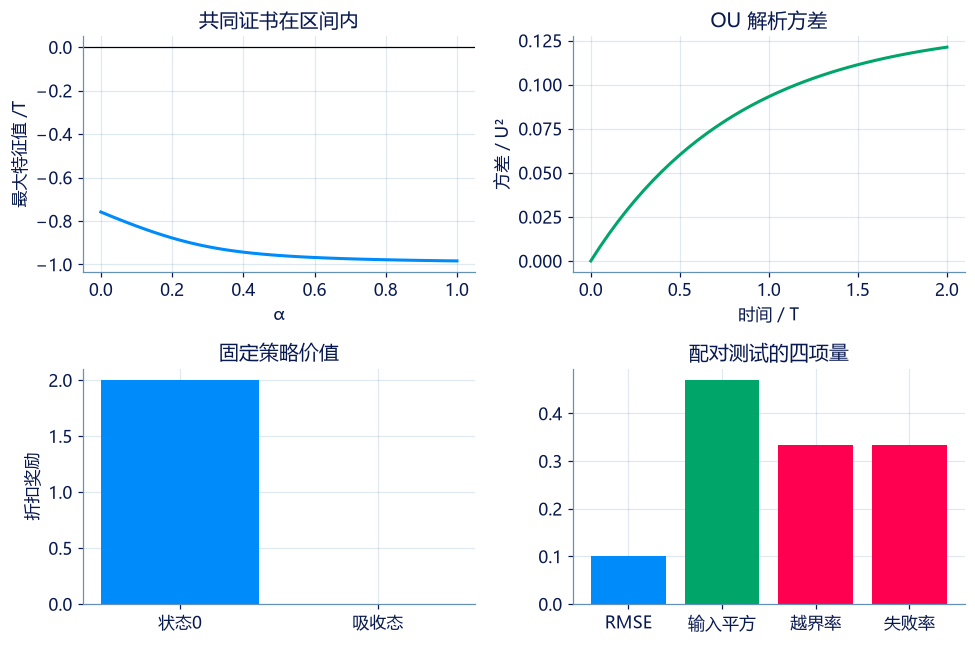

共同证书： [1.0, [-0.7585786437626905, -0.983772233983162], True]
配对决策指标： [0.1, 0.47000000000000003, 0.3333333333333333, 0.3333333333333333]


In [4]:
A0=[[-.4,.1],[0.,-.5]];A1=[[-.8,.1],[0.,-.5]];P=np.eye(2)
alphas=np.linspace(0,1,41)
margins=[common_quadratic([affine_vertex(A0,A1,t)],P)[1][0] for t in alphas]
times=np.linspace(0,2,41)
variances=[ou_moments(1.,.6,.4,t)[1] for t in times]
transitions=[[[1.,0.]],[[0.,1.]]];rewards=[[1.],[0.]]
values=policy_values(transitions,rewards,[0,0],.5)
metrics=decision_metrics([.7,1.2,1.4],[.8,1.1,1.5],[.2,1.1,.4],1.,[False,True,False])
fig,axes=plt.subplots(2,2,figsize=(9,6))
axes[0,0].plot(alphas,margins,color=BLUE);axes[0,0].axhline(0,color='black',lw=.8);axes[0,0].set(title='共同证书在区间内',xlabel='α',ylabel='最大特征值 /T')
axes[0,1].plot(times,variances,color=GREEN);axes[0,1].set(title='OU 解析方差',xlabel='时间 / T',ylabel='方差 / U²')
axes[1,0].bar(['状态0','吸收态'],values,color=[BLUE,GREEN]);axes[1,0].set(title='固定策略价值',ylabel='折扣奖励')
axes[1,1].bar(['RMSE','输入平方','越界率','失败率'],metrics,color=[BLUE,GREEN,PINK,PINK]);axes[1,1].set(title='配对测试的四项量')
for ax in axes.flat:ax.grid(alpha=.2)
fig.tight_layout();plt.show()
print('共同证书：',common_quadratic([A0,A1],P))
print('配对决策指标：',metrics)

## 结果解释

这个小型例子中的顶点证书覆盖指定矩阵区间；随机方差是模型下的解析量；价值只针对给定策略与转移表；动作越界和求解失败不能由预测 RMSE 代替。图上的有限扫描与测试不能外推到未经声明的模型、干预或人群。

### 独立核对

分别核对凸组合、随机无漂移极限（limit）、Bellman 方程和失败率。

In [5]:
assert common_quadratic([A0,A1],P)[2]
np.testing.assert_allclose(affine_vertex(A0,A1,.5),(.5*np.asarray(A0)+.5*np.asarray(A1)))
np.testing.assert_allclose(ou_moments(0.,0.,2.,.5),[0.,2.])
np.testing.assert_allclose(values,[2.,0.])
assert metrics[2]==1/3 and metrics[3]==1/3
assert constrained_action(3.,0.,1.,[0.,1.],1.,0.,2.,.1) is None
print('四种独立条件与无可行候选检查通过。')

四种独立条件与无可行候选检查通过。


## 练习与参考资料

先独立作答，再提交核对。

本篇综合题按基础辨析、方法应用、综合验证、迁移挑战递进，共 100 分。每题独立作答；正确选择或完整测试通过得该题全部分值。网页分别汇总首次作答分与练习达成分，支持按层次和学习目标复习。

### 第 1 题 · 基础辨析 · 10 分 · 单项选择题：稳定保证的适用范围

共同二次证书只在已声明仿射（affine）凸包内成立；一个外部模型（model）发散时，怎样陈述？

- **A.** 外部模型自动推翻凸包内证明。
- **B.** 凸包内结论保留，外部模型另作判断。
- **C.** 所有闭环模型都失稳。
- **D.** 有限仿真已经取代证书。

[作答：稳定保证的适用范围](http://127.0.0.1:8000/parts/16-%E8%87%AA%E9%80%82%E5%BA%94%E3%80%81%E9%B2%81%E6%A3%92%E4%B8%8E%E5%AD%A6%E4%B9%A0%E6%8E%A7%E5%88%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p16-capstone-scope)

### 第 2 题 · 基础辨析 · 10 分 · 单项选择题：随机路径的比较

比较两种步长的随机离散状态（state）误差时，什么设计支持同一路径比较？

- **A.** 粗细各自独立抽样。
- **B.** 只比较两条最好看的曲线。
- **C.** 细增量按粗区间求和构造粗增量。
- **D.** 把所有负增量设为零。

[作答：随机路径的比较](http://127.0.0.1:8000/parts/16-%E8%87%AA%E9%80%82%E5%BA%94%E3%80%81%E9%B2%81%E6%A3%92%E4%B8%8E%E5%AD%A6%E4%B9%A0%E6%8E%A7%E5%88%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p16-capstone-random)

### 第 3 题 · 方法应用 · 15 分 · 单项选择题：有限训练的强化学习证据

给定短经验序列，训练内回报上升能够证明什么？

- **A.** 已达到原论文的渐近收敛前提。
- **B.** 在任何真实环境都安全。
- **C.** 价值函数等于策略的因果效用。
- **D.** 只支持这套训练和评估协议下的有限表现。

[作答：有限训练的强化学习证据](http://127.0.0.1:8000/parts/16-%E8%87%AA%E9%80%82%E5%BA%94%E3%80%81%E9%B2%81%E6%A3%92%E4%B8%8E%E5%AD%A6%E4%B9%A0%E6%8E%A7%E5%88%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p16-capstone-learning)

### 第 4 题 · 方法应用 · 15 分 · 单项选择题：预测与决策结论

学习预测器 RMSE 较低，但约束违约率和失败率较高，应保留什么结论？

- **A.** RMSE 最优就说明控制器最安全。
- **B.** 四项指标分别报告，并说明预测改善未转成安全保证。
- **C.** 只删除失败场景。
- **D.** 把约束改宽再称原问题成功。

[作答：预测与决策结论](http://127.0.0.1:8000/parts/16-%E8%87%AA%E9%80%82%E5%BA%94%E3%80%81%E9%B2%81%E6%A3%92%E4%B8%8E%E5%AD%A6%E4%B9%A0%E6%8E%A7%E5%88%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p16-capstone-failure)

### 第 5 题 · 综合验证 · 15 分 · Python 计算题：综合：核验共同证书

在统一的不确定集合上检查同一 P 的顶点条件，并保留全部特征值（eigenvalue）证据。

**函数与代码模板**

```python
def solve(
    vertices: list[list[list[float]]],
    P: list[list[float]],
) -> list:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `vertices` | `list[list[list[float]]]` | 二维模型（model）集合的顶点。 | 1/T |
| `P` | `list[list[float]]` | 统一候选矩阵（matrix）。 | 按状态尺度 |

**返回值**

直接返回 result（list）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `result` | `list` | P 最小特征值、各顶点导数（derivative）最大特征值、严格判定。 | 混合 |

**计算规则**

P 最小特征值应为正；逐顶点计算对称矩阵 AᵀP+PA 的最大特征值，均严格小于0才返回 True。

**约束与边界**

- 至少一个二维实矩阵顶点；P 为二维实对称候选矩阵；所有输入（input）有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| vertices | 二维模型（model）集合的顶点。 | [[[-1.0, 0.0], [0.0, -2.0]], [[-0.4, 0.0], [0.0, -0.8]]] | 1/T |
| P | 统一候选矩阵（matrix）。 | [[1.0, 0.0], [0.0, 1.0]] | 按状态尺度 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
vertices = [[[-1.0, 0.0], [0.0, -2.0]],
            [[-0.4, 0.0], [0.0, -0.8]]]
P = [[1.0, 0.0], [0.0, 1.0]]

result = solve(vertices, P)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| result | P 最小特征值、各顶点导数（derivative）最大特征值、严格判定。 | [1.0, [-2.0, -0.8], True] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1.0, [-2.0, -0.8], True]
```

**样例解释**

首例 P 正定（positive definite）且两端导数矩阵负定，故整个仿射（affine）凸包获得此共同证书。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合：核验共同证书](http://127.0.0.1:8000/parts/16-%E8%87%AA%E9%80%82%E5%BA%94%E3%80%81%E9%B2%81%E6%A3%92%E4%B8%8E%E5%AD%A6%E4%B9%A0%E6%8E%A7%E5%88%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p16-capstone-certificate)

### 第 6 题 · 综合验证 · 15 分 · Python 计算题：综合：独立核验随机终点

由解析 OU 公式返回均值和方差（variance），作为随机离散重复实验的对照。

**函数与代码模板**

```python
def solve(
    x0: float,
    a: float,
    sigma: float,
    time: float,
) -> tuple[float, float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x0` | `float` | 确定初态。 | U |
| `a` | `float` | 恢复率。 | 1/T |
| `sigma` | `float` | 噪声幅度。 | U/√T |
| `time` | `float` | 终点。 | T |

**返回值**

按以下顺序返回元组：(mean, variance)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mean` | `float` | 解析期望（expectation）。 | U |
| `variance` | `float` | 解析方差。 | U² |

**计算规则**

均值=x0*exp(-a*time)；a>0 时方差=sigma²*(1-exp(-2a*time))/(2a)，a=0 时为 sigma²*time。

**约束与边界**

- a≥0、sigma≥0、time≥0；全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x0 | 确定初态。 | 0 | U |
| a | 恢复率。 | 0 | 1/T |
| sigma | 噪声幅度。 | 1 | U/√T |
| time | 终点。 | 2 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x0 = 0.0
a = 0.0
sigma = 1.0
time = 2.0

result = solve(x0, a, sigma, time)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| mean | 解析期望（expectation）。 | 0 | U |
| variance | 解析方差。 | 2 | U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.0, 2.0)
```

**样例解释**

首例是标准布朗扩散的数值尺度，终点均值0、方差2。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合：独立核验随机终点](http://127.0.0.1:8000/parts/16-%E8%87%AA%E9%80%82%E5%BA%94%E3%80%81%E9%B2%81%E6%A3%92%E4%B8%8E%E5%AD%A6%E4%B9%A0%E6%8E%A7%E5%88%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p16-capstone-stochastic)

### 第 7 题 · 迁移挑战 · 10 分 · Python 计算题：综合：固定策略的独立价值

对给定有限 MDP 解 Bellman 方程，不读取训练过程的 Q 表。

**函数与代码模板**

```python
def solve(
    transitions: list,
    rewards: list,
    policy: list[int],
    gamma: float,
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `transitions` | `list` | 状态（state）×动作×后继状态概率（probability）。 | 1 |
| `rewards` | `list` | 状态×动作即时奖励。 | 奖励 |
| `policy` | `list[int]` | 固定策略。 | 1 |
| `gamma` | `float` | 折扣因子。 | 1 |

**返回值**

直接返回 values（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `values` | `list[float]` | 各状态的期望（expectation）折扣价值。 | 奖励 |

**计算规则**

按固定 policy 抽取 P_pi 与 r_pi，求解 (I-gamma*P_pi)V=r_pi。

**约束与边界**

- 2—8 个状态，每状态1—4个动作；转移非负且每行和为1；policy 动作合法，0≤gamma<1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| transitions | 状态（state）×动作×后继状态概率（probability）。 | [[[1.0, 0.0]], [[0.0, 1.0]]] | 1 |
| rewards | 状态×动作即时奖励。 | [[1.0], [0.0]] | 奖励 |
| policy | 固定策略。 | [0, 0] | 1 |
| gamma | 折扣因子。 | 0.5 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
transitions = [[[1.0, 0.0]], [[0.0, 1.0]]]
rewards = [[1.0], [0.0]]
policy = [0, 0]
gamma = 0.5

result = solve(transitions, rewards, policy, gamma)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| values | 各状态的期望（expectation）折扣价值。 | [2.0, 0.0] | 奖励 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [2.0, 0.0]
```

**样例解释**

首例状态0反复得到1，折扣价值2；吸收态（absorbing state）价值0。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合：固定策略的独立价值](http://127.0.0.1:8000/parts/16-%E8%87%AA%E9%80%82%E5%BA%94%E3%80%81%E9%B2%81%E6%A3%92%E4%B8%8E%E5%AD%A6%E4%B9%A0%E6%8E%A7%E5%88%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p16-capstone-policy)

### 第 8 题 · 迁移挑战 · 10 分 · Python 计算题：综合：配对报告四项指标

对完整共同测试集（test set）返回预测误差、动作成本、实际动作越界率和求解失败率。

**函数与代码模板**

```python
def solve(
    truth: list[float],
    prediction: list[float],
    inputs: list[float],
    limit: float,
    failures: list[bool],
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `truth` | `list[float]` | 各场景真实后继状态（state）。 | U |
| `prediction` | `list[float]` | 同场景预测。 | U |
| `inputs` | `list[float]` | 实际执行动作。 | U |
| `limit` | `float` | 动作绝对上限。 | U |
| `failures` | `list[bool]` | 求解失败标志。 | 1 |

**返回值**

直接返回 metrics（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `metrics` | `list[float]` | RMSE、动作平方均值、越界率、失败率。 | 混合 |

**计算规则**

四项依次为预测 RMSE、实际动作平方均值、实际动作绝对值超过 limit 的比例、求解失败比例；所有场景均保留。

**约束与边界**

- 五个列表长度相同且非空，长度≤100；limit≥0；全部数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| truth | 各场景真实后继状态（state）。 | [0.0, 1.0] | U |
| prediction | 同场景预测。 | [0.0, 1.0] | U |
| inputs | 实际执行动作。 | [0.1, 1.5] | U |
| limit | 动作绝对上限。 | 1 | U |
| failures | 求解失败标志。 | [False, True] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
truth = [0.0, 1.0]
prediction = [0.0, 1.0]
inputs = [0.1, 1.5]
limit = 1.0
failures = [False, True]

result = solve(truth, prediction, inputs, limit, failures)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| metrics | RMSE、动作平方均值、越界率、失败率。 | [0.0, 1.13, 0.5, 0.5] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [0.0, 1.13, 0.5, 0.5]
```

**样例解释**

首例预测完全正确，但两个实际动作中一个越界且求解失败，不能报告为无风险。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：综合：配对报告四项指标](http://127.0.0.1:8000/parts/16-%E8%87%AA%E9%80%82%E5%BA%94%E3%80%81%E9%B2%81%E6%A3%92%E4%B8%8E%E5%AD%A6%E4%B9%A0%E6%8E%A7%E5%88%B6/%E7%BB%BC%E5%90%88%E7%BB%83%E4%B9%A0/practice/?question=p16-capstone-decision)

**进一步阅读**

[Boyd 等的 LMI 专著](https://web.stanford.edu/~boyd/lmibook/)、[Watkins 与 Dayan 的 Q-learning 原论文](https://www.gatsby.ucl.ac.uk/~dayan/papers/cjch.pdf)、[Olfati-Saber 等的一致性综述](https://www.cds.caltech.edu/~murray/papers/2007c_ofm07-ieeeproc.html)。